<a href="https://colab.research.google.com/github/madhavi-analytics/COUNTRY_CLUSTERING-/blob/main/Country_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **COUNTRY CLUSTERING BUSINESS**

---



In [ ]:
import pandas as pd
import numpy as np

**IMPORT RAW DATA**

In [ ]:
df=pd.read_csv("/content/Country-data.csv")
print(df)

                 country  child_mort  exports  health  imports  income  \
0            Afghanistan        90.2     10.0    7.58     44.9    1610   
1                Albania        16.6     28.0    6.55     48.6    9930   
2                Algeria        27.3     38.4    4.17     31.4   12900   
3                 Angola       119.0     62.3    2.85     42.9    5900   
4    Antigua and Barbuda        10.3     45.5    6.03     58.9   19100   
..                   ...         ...      ...     ...      ...     ...   
162              Vanuatu        29.2     46.6    5.25     52.7    2950   
163            Venezuela        17.1     28.5    4.91     17.6   16500   
164              Vietnam        23.3     72.0    6.84     80.2    4490   
165                Yemen        56.3     30.0    5.18     34.4    4480   
166               Zambia        83.1     37.0    5.89     30.9    3280   

     inflation  life_expec  total_fer   gdpp  
0         9.44        56.2       5.82    553  
1         4.49   

In [ ]:
df.columns

Index(['country', 'child_mort', 'exports', 'health', 'imports', 'income',
       'inflation', 'life_expec', 'total_fer', 'gdpp', 'cluster'],
      dtype='object')

# **Features explanation**

**country**
→ Name of the country

**child_mort**
→ Number of child deaths (under age 5) per 1000 births

**exports**
→ Exports of goods and services (% of GDP)

**health**
→ Health spending as % of GDP

**imports**
→ Imports of goods and services (% of GDP)

**income**
→ Net income per person (in USD)

**inflation**
→ Annual growth rate of GDP (%)

**life_expec**
→ Average life expectancy (in years)

**total_fer**
→ Average number of children per woman

**gdpp**
→ GDP per person (in USD)








In [ ]:
df.head(10)

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.440,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.490,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.100,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.400,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.440,76.8,2.13,12200
5,Argentina,14.5,18.9,8.10,16.0,18700,20.900,75.8,2.37,10300
6,Armenia,18.1,20.8,4.40,45.3,6700,7.770,73.3,1.69,3220
7,Australia,4.8,19.8,8.73,20.9,41400,1.160,82.0,1.93,51900
8,Austria,4.3,51.3,11.00,47.8,43200,0.873,80.5,1.44,46900
9,Azerbaijan,39.2,54.3,5.88,20.7,16000,13.800,69.1,1.92,5840


In [ ]:
df.tail(10)

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
157,United Arab Emirates,8.6,77.7,3.66,63.6,57600,12.50,76.5,1.87,35000
158,United Kingdom,5.2,28.2,9.64,30.8,36200,1.57,80.3,1.92,38900
159,United States,7.3,12.4,17.90,15.8,49400,1.22,78.7,1.93,48400
160,Uruguay,10.6,26.3,8.35,25.4,17100,4.91,76.4,2.08,11900
161,Uzbekistan,36.3,31.7,5.81,28.5,4240,16.50,68.8,2.34,1380
162,Vanuatu,29.2,46.6,5.25,52.7,2950,2.62,63.0,3.50,2970
163,Venezuela,17.1,28.5,4.91,17.6,16500,45.90,75.4,2.47,13500
164,Vietnam,23.3,72.0,6.84,80.2,4490,12.10,73.1,1.95,1310
165,Yemen,56.3,30.0,5.18,34.4,4480,23.60,67.5,4.67,1310
166,Zambia,83.1,37.0,5.89,30.9,3280,14.00,52.0,5.40,1460


In [ ]:
df.describe

<bound method NDFrame.describe of                  country  child_mort  exports  health  imports  income  \
0            Afghanistan        90.2     10.0    7.58     44.9    1610   
1                Albania        16.6     28.0    6.55     48.6    9930   
2                Algeria        27.3     38.4    4.17     31.4   12900   
3                 Angola       119.0     62.3    2.85     42.9    5900   
4    Antigua and Barbuda        10.3     45.5    6.03     58.9   19100   
..                   ...         ...      ...     ...      ...     ...   
162              Vanuatu        29.2     46.6    5.25     52.7    2950   
163            Venezuela        17.1     28.5    4.91     17.6   16500   
164              Vietnam        23.3     72.0    6.84     80.2    4490   
165                Yemen        56.3     30.0    5.18     34.4    4480   
166               Zambia        83.1     37.0    5.89     30.9    3280   

     inflation  life_expec  total_fer   gdpp  
0         9.44        56.2       5.82    553  
1         4.49        76.3       1.65   4090  
2        16.10        76.5       2.89   4460  
3        22.40        60.1       6.16   3530  
4         1.44        76.8       2.13  12200  
..         ...         ...        ...    ...  
162       2.62        63.0       3.50   2970  
163      45.90        75.4       2.47  13500  
164      12.10        73.1       1.95   1310  
165      23.60        67.5       4.67   1310  
166      14.00        52.0       5.40   1460  

[167 rows x 10 columns]>

In [ ]:
df.shape

(167, 11)

# **Category Mapping**

Economic -
income, gdpp, exports, imports, inflation

Health -child_mort, health, life_expec

Social -
total_fer

**check missing values**

In [ ]:
print(df.isnull().sum())

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64


In [ ]:
print(df.duplicated().sum())

0


**scaling require**

* Features like income (large values) dominate clustering  



In [ ]:
from sklearn.preprocessing import StandardScaler

X = df.drop('country', axis=1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(X)

     child_mort  exports  health  imports  income  inflation  life_expec  \
0          90.2     10.0    7.58     44.9    1610       9.44        56.2   
1          16.6     28.0    6.55     48.6    9930       4.49        76.3   
2          27.3     38.4    4.17     31.4   12900      16.10        76.5   
3         119.0     62.3    2.85     42.9    5900      22.40        60.1   
4          10.3     45.5    6.03     58.9   19100       1.44        76.8   
..          ...      ...     ...      ...     ...        ...         ...   
162        29.2     46.6    5.25     52.7    2950       2.62        63.0   
163        17.1     28.5    4.91     17.6   16500      45.90        75.4   
164        23.3     72.0    6.84     80.2    4490      12.10        73.1   
165        56.3     30.0    5.18     34.4    4480      23.60        67.5   
166        83.1     37.0    5.89     30.9    3280      14.00        52.0   

     total_fer   gdpp  
0         5.82    553  
1         1.65   4090  
2         2.89 

# **why feature scaling is critical before clustering**

**All features are not equal in size**
→ Some values are big (income), some are small (health)

**Clustering uses distance**
→ It checks how far data points are

**Big values dominate**
→ Large features (income) control the result
→ Small features get ignored

**Scaling makes all features equal**
→ Every feature gets same importance

**Gives correct clusters**
→ Countries are grouped properly

**Improves accuracy**
→ Better and meaningful results

# **Exploratory Data Analysis(EDA)**

**Country with extreme values**


 **Highest Income**

In [ ]:
df.sort_values(by='income', ascending=False)[['country','income']].head()

,country,income
123,Qatar,125000
91,Luxembourg,91700
23,Brunei,80600
82,Kuwait,75200
133,Singapore,72100


**Highest child Mortality**

In [ ]:
df.sort_values(by='child_mort', ascending=False)[['country','child_mort']].head()

,country,child_mort
66,Haiti,208.0
132,Sierra Leone,160.0
32,Chad,150.0
31,Central African Republic,149.0
97,Mali,137.0


**High life Expectancy**

In [ ]:
df.sort_values(by='life_expec', ascending=False)[['country','life_expec']].head()

,country,life_expec
77,Japan,82.8
133,Singapore,82.7
145,Switzerland,82.2
68,Iceland,82.0
7,Australia,82.0


**Disturbution plots**

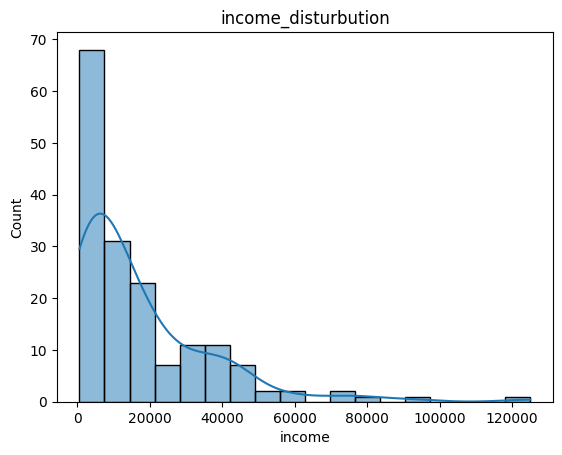

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['income'], kde=True)
plt.title('income_disturbution')
plt.show()


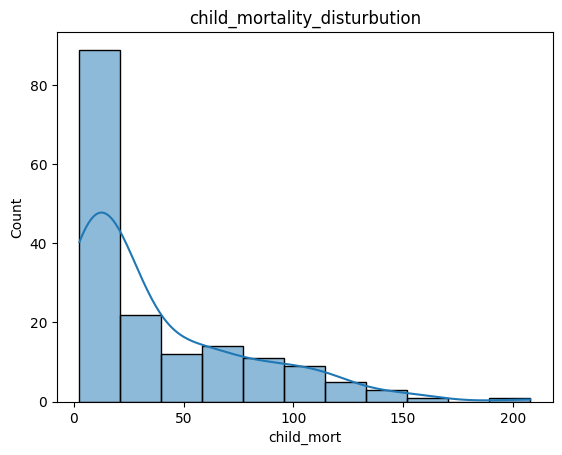

In [ ]:
sns.histplot(df['child_mort'], kde=True)
plt.title('child_mortality_disturbution')
plt.show()


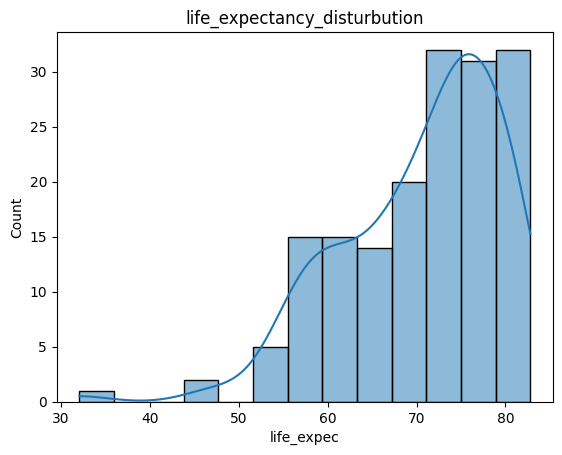

In [ ]:
sns.histplot(df['life_expec'], kde=True)
plt.title('life_expectancy_disturbution')
plt.show()

# **overall insights from this plots**



--> Most countries fall in low to medium income range


--> Only a few countries have very high income (developed countries)

--> Child mortality is low for most countries, but some countries show very high values

--> High child mortality indicates poor healthcare and living conditions

--> Life expectancy is high for most countries

--> Few countries have low life expectancy, showing weaker health systems


* High income → developed countries

* High child mortality → poor countries

* High life expectancy → developed





# **Feature selection Clusturing**

**Use All Features**
* Because all represent development indicators.

**Exclude Country**
* Covers rconomic + health + social factors

# **Clustering (K-Means)**

In [ ]:

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

X = df[['child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = KMeans(n_clusters=3, random_state=42)
df['cluster'] = model.fit_predict(X_scaled)

centroids = model.cluster_centers_
print('centroids: ', centroids)
print('Inertia :', model.inertia_)
print('silhouette_score:', silhouette_score(X_scaled, df['cluster']))
print(df)
df.head(20)

centroids:  [[-0.39328196 -0.03058375 -0.20617903  0.01956247 -0.25093021 -0.00578315
   0.22676244 -0.40257862 -0.35583225]
 [-0.82744866  0.64507985  0.72741122  0.19063895  1.48424268 -0.48492064
   1.07957853 -0.79187687  1.61599536]
 [ 1.41356446 -0.45761494 -0.18789794 -0.18989721 -0.70783863  0.39898875
  -1.29703104  1.40287396 -0.61276131]]
Inertia : 831.5351582151586
silhouette_score: 0.285600988953231
                 country  child_mort  exports  health  imports  income  \
0            Afghanistan        90.2     10.0    7.58     44.9    1610   
1                Albania        16.6     28.0    6.55     48.6    9930   
2                Algeria        27.3     38.4    4.17     31.4   12900   
3                 Angola       119.0     62.3    2.85     42.9    5900   
4    Antigua and Barbuda        10.3     45.5    6.03     58.9   19100   
..                   ...         ...      ...     ...      ...     ...   
162              Vanuatu        29.2     46.6    5.25     52.7    

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,cluster
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.440,56.2,5.82,553,2
1,Albania,16.6,28.0,6.55,48.6,9930,4.490,76.3,1.65,4090,0
2,Algeria,27.3,38.4,4.17,31.4,12900,16.100,76.5,2.89,4460,0
3,Angola,119.0,62.3,2.85,42.9,5900,22.400,60.1,6.16,3530,2
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.440,76.8,2.13,12200,0
5,Argentina,14.5,18.9,8.10,16.0,18700,20.900,75.8,2.37,10300,0
6,Armenia,18.1,20.8,4.40,45.3,6700,7.770,73.3,1.69,3220,0
7,Australia,4.8,19.8,8.73,20.9,41400,1.160,82.0,1.93,51900,1
8,Austria,4.3,51.3,11.00,47.8,43200,0.873,80.5,1.44,46900,1
9,Azerbaijan,39.2,54.3,5.88,20.7,16000,13.800,69.1,1.92,5840,0


**Why K-Means?**

* Simple and fast

* Works well for numerical data

* Easy to interpret

**Hierarchical clustering**

In [ ]:

from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.metrics import silhouette_score

X = df[['child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = AgglomerativeClustering(n_clusters=3)
df['cluster'] = model.fit_predict(X_scaled)

print('silhouette_score: ', silhouette_score(X_scaled, df['cluster']))
print(df)
df.head(60)

silhouette_score:  0.24563001303300652
                 country  child_mort  exports  health  imports  income  \
0            Afghanistan        90.2     10.0    7.58     44.9    1610   
1                Albania        16.6     28.0    6.55     48.6    9930   
2                Algeria        27.3     38.4    4.17     31.4   12900   
3                 Angola       119.0     62.3    2.85     42.9    5900   
4    Antigua and Barbuda        10.3     45.5    6.03     58.9   19100   
..                   ...         ...      ...     ...      ...     ...   
162              Vanuatu        29.2     46.6    5.25     52.7    2950   
163            Venezuela        17.1     28.5    4.91     17.6   16500   
164              Vietnam        23.3     72.0    6.84     80.2    4490   
165                Yemen        56.3     30.0    5.18     34.4    4480   
166               Zambia        83.1     37.0    5.89     30.9    3280   

     inflation  life_expec  total_fer   gdpp  cluster  
0         9.44  

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,cluster
0,Afghanistan,90.2,10.00,7.58,44.9,1610,9.440,56.2,5.82,553,2
1,Albania,16.6,28.00,6.55,48.6,9930,4.490,76.3,1.65,4090,1
2,Algeria,27.3,38.40,4.17,31.4,12900,16.100,76.5,2.89,4460,1
3,Angola,119.0,62.30,2.85,42.9,5900,22.400,60.1,6.16,3530,1
4,Antigua and Barbuda,10.3,45.50,6.03,58.9,19100,1.440,76.8,2.13,12200,1
5,Argentina,14.5,18.90,8.10,16.0,18700,20.900,75.8,2.37,10300,1
6,Armenia,18.1,20.80,4.40,45.3,6700,7.770,73.3,1.69,3220,1
7,Australia,4.8,19.80,8.73,20.9,41400,1.160,82.0,1.93,51900,0
8,Austria,4.3,51.30,11.00,47.8,43200,0.873,80.5,1.44,46900,0
9,Azerbaijan,39.2,54.30,5.88,20.7,16000,13.800,69.1,1.92,5840,1


**Note:**
    This code groups countries into clusters based on socio-economic and health indicators using hierarchical clustering, and evaluates the quality using silhouette score.

# **Optimal clusters(Elbow Method)**

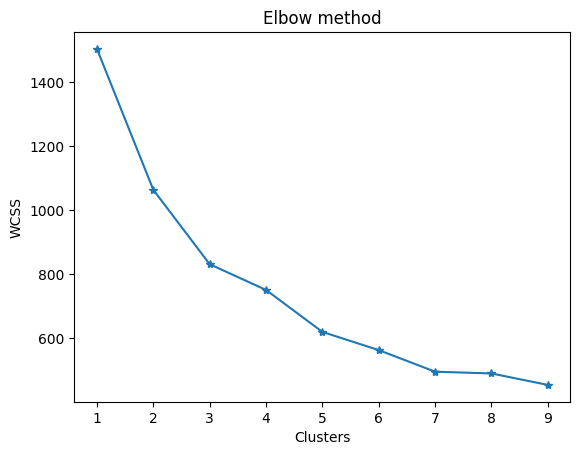

In [ ]:
wcss = []

for i in range(1, 10):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,10), wcss,marker='*')
plt.xlabel('Clusters')
plt.ylabel('WCSS')
plt.title('Elbow method')
plt.show()

 **Elbow Method Insights**

The graph shows WCSS (Within Cluster Sum of Squares) vs number of clusters
WCSS decreases as the number of clusters increases

→ Because more clusters = better grouping
Initially, there is a sharp decrease in WCSS

→ Adding clusters improves model significantly
After a certain point, the decrease becomes slow and gradual

This point (bend in graph) is called the “Elbow Point”

# **Dendogram cluster**

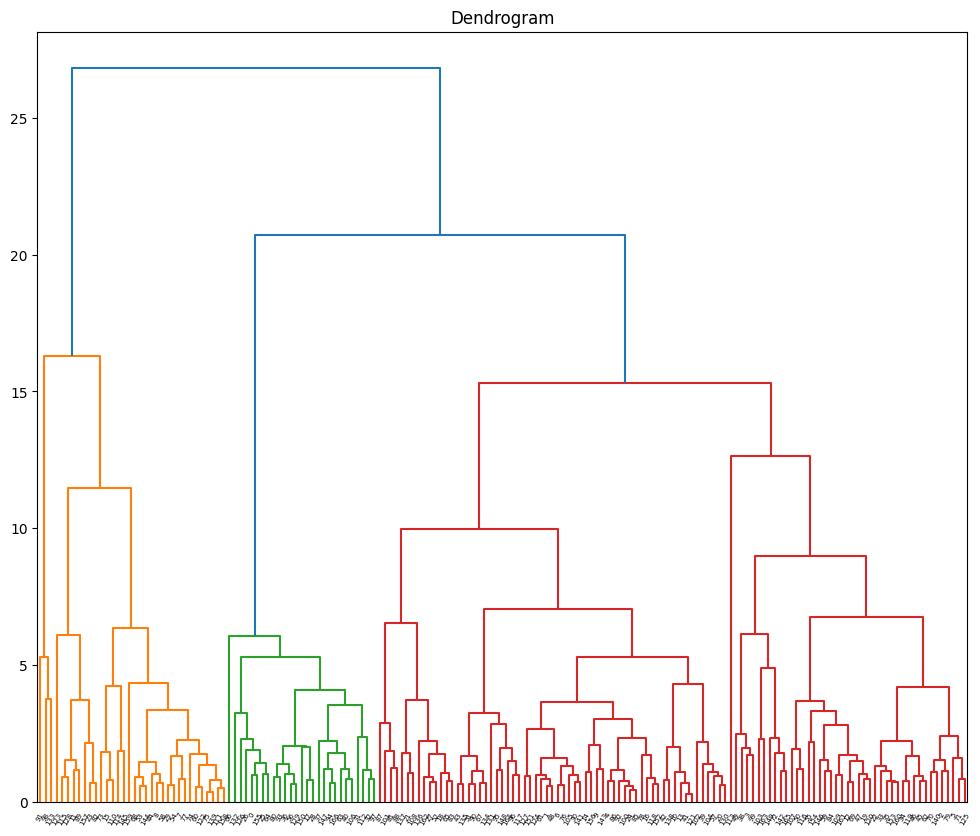

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt
plt.figure(figsize=(12,10))
linked=linkage(X_scaled, method='ward')
dendrogram(linked)
plt.xticks(rotation=60)
plt.title('Dendrogram')
plt.show()

**Cluster Interpretation**

The dendrogram shows clear separation of countries into 3 meaningful clusters based on development indicators.

One cluster contains countries with:
→ Low income, high child mortality, low life expectancy
* Underdeveloped countries

Second cluster shows:
→ Moderate values
* Developing countries

Third cluster shows:
→ High income, low mortality, high life expectancy
 * Developed countries



#**Cluster Profiling**

**mean values**

In [ ]:
cluster_profile = df.groupby('cluster').mean(numeric_only=True)
print(cluster_profile)

         child_mort    exports    health    imports        income  inflation  \
cluster                                                                        
0         22.456977  40.273128  6.251047  47.362394  12321.744186   7.720884   
1          5.000000  58.738889  8.807778  51.491667  45672.222222   2.671250   
2         95.106667  28.602444  6.301111  42.306667   3539.844444  11.986778   

         life_expec  total_fer          gdpp  
cluster                                       
0         72.566279   2.340349   6461.767442  
1         80.127778   1.752778  42494.444444  
2         59.055556   5.065333   1766.711111  


# **Interpretation**

**Cluster type**

0 - Developed

1 - Developing

2 - Underdeveloped

**Example**

High income + high life → Developed

High child mortality → Underdeveloped

# **Visualization**

**PCA for 2D plot**

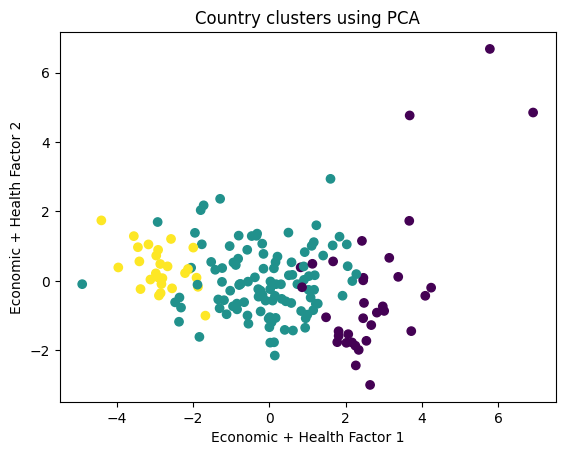

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.scatter(X_pca[:,0], X_pca[:,1], c=df['cluster'])
plt.xlabel('Economic + Health Factor 1')
plt.ylabel('Economic + Health Factor 2')
plt.title('Country clusters using PCA')
plt.show()

**NOTE:**

* Countries are clearly separated into 3 clusters

* Similar countries are grouped close together

* PCA helps visualize high-dimensional data in 2D